# Part 1. 회귀 기초 · Loss · 다항 과적합 · 평가 지표

- **데이터**: Seaborn 내장 `tips` (팁 예측), `diamonds` (가격 예측 보조)

---
## 0. 환경 설정


### 문제 1. 라이브러리 임포트


In [1]:
import sys

# 1. OS 환경 확인 및 리눅스(Ubuntu) 환경일 경우 나눔 폰트 설치
# 맷플롯립(Matplotlib)의 한글 깨짐 현상을 방지하기 위한 작업입니다.
if sys.platform != 'darwin':  # macOS('darwin')가 아닌 경우 (즉, Colab 등 리눅스 환경)
    # 나눔 폰트를 조용히(quiet) 설치합니다.
    !sudo apt-get install -y -qq fonts-nanum 2>/dev/null
    # 시스템 폰트 캐시를 갱신합니다.
    !fc-cache -fv 2>/dev/null
    # 맷플롯립의 기존 폰트 캐시를 삭제하여 새로 설치된 폰트를 인식하게 합니다.
    !rm -rf ~/.cache/matplotlib 2>/dev/null

# 2. 필수 라이브러리 로드
import numpy as np                          # 수치 계산 및 배열 처리를 위한 라이브러리
import pandas as pd                         # 데이터프레임 활용 데이터 분석 라이브러리
import matplotlib.pyplot as plt             # 데이터 시각화(기본 그래프) 라이브러리
import matplotlib.font_manager as fm        # 맷플롯립 폰트 관리 모듈
import seaborn as sns                       # Matplotlib 기반의 고급 통계 시각화 라이브러리

# 3. 머신러닝 알고리즘 및 평가 지표 로드 (사이킷런)
from sklearn.linear_model import LinearRegression           # 선형 회귀 모델
from sklearn.preprocessing import PolynomialFeatures        # 다항 회귀 생성을 위한 특성 변환 모듈
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score # 평가지표 (MSE, MAE, R²)

# 4. 경고 메시지 제어
import warnings
warnings.filterwarnings('ignore') # 분석 흐름을 방해하는 불필요한 경고(Warning) 메시지를 숨깁니다.

# 5. 맷플롯립에 나눔 폰트 등록
# 리눅스 시스템 경로와 macOS 폰트 경로에서 나눔 폰트를 찾아 맷플롯립 내장 폰트 매니저에 추가합니다.
for d in ['/usr/share/fonts/truetype/nanum', '/Library/Fonts']:
    for ff in fm.findSystemFonts(fontpaths=[d]):
        fm.fontManager.addfont(ff)

# 6. 시각화 기본 스타일 및 한글 설정 세팅
# 그래프 기본 폰트를 'NanumBarunGothic'으로 설정하고, 마이너스(-) 기호 깨짐을 방지합니다.
plt.rcParams.update({'font.family': 'NanumBarunGothic', 'axes.unicode_minus': False, 'figure.dpi': 110})
# Seaborn 테마를 하얀 그리드 배경으로 설정하고 동일하게 한글 설정을 적용합니다.
sns.set_theme(style='whitegrid', font='NanumBarunGothic', rc={'axes.unicode_minus': False})

# 7. 난수 생성 고정 (재현성 확보)
# 분석을 실행할 때마다 동일한 무작위 데이터나 데이터 분할 결과를 얻기 위해 시드(Seed)를 고정합니다.
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

Selecting previously unselected package fonts-nanum.
(Reading database ... 118243 files and directories currently installed.)
Preparing to unpack .../fonts-nanum_20200506-1_all.deb ...
Unpacking fonts-nanum (20200506-1) ...
Setting up fonts-nanum (20200506-1) ...
Processing triggers for fontconfig (2.13.1-4.2ubuntu5) ...
/usr/share/fonts: caching, new cache contents: 0 fonts, 1 dirs
/usr/share/fonts/truetype: caching, new cache contents: 0 fonts, 3 dirs
/usr/share/fonts/truetype/humor-sans: caching, new cache contents: 1 fonts, 0 dirs
/usr/share/fonts/truetype/liberation: caching, new cache contents: 16 fonts, 0 dirs
/usr/share/fonts/truetype/nanum: caching, new cache contents: 12 fonts, 0 dirs
/usr/local/share/fonts: caching, new cache contents: 0 fonts, 0 dirs
/root/.local/share/fonts: skipping, no such directory
/root/.fonts: skipping, no such directory
/usr/share/fonts/truetype: skipping, looped directory detected
/usr/share/fonts/truetype/humor-sans: skipping, looped directory det

### 문제 2. Seaborn `tips` 로드 및 `.loc` 파생 변수



In [2]:
# 1. Seaborn 내장 데이터셋 로드 및 구조 확인
# 'tips'(식당 팁 정보) 데이터셋을 가져와 전체 행과 열의 크기(Shape)를 출력합니다.
tips = sns.load_dataset('tips')
print('shape:', tips.shape)

# 2. 데이터 유실 및 원본 보존을 위한 데이터프레임 복사
df = tips.copy()

# 3. .loc 인덱서를 활용한 파생 변수(New Columns) 생성
# .loc[행_슬라이싱, 열_이름] 구조를 사용하여 안전하게 새로운 컬럼을 추가합니다.

# 'bill_per_person': 전체 식사 금액(total_bill)을 일행 수(size)로 나눈 1인당 식사 금액
df.loc[:, 'bill_per_person'] = df.loc[:, 'total_bill'] / df.loc[:, 'size']

# 'tip_rate': 전체 식사 금액(total_bill) 대비 팁(tip)의 비율
df.loc[:, 'tip_rate'] = df.loc[:, 'tip'] / df.loc[:, 'total_bill']

# 4. 새로 생성된 파생 변수를 포함하여 상위 5개 행(Head) 출력
print(df.loc[:, ['total_bill', 'size', 'tip', 'bill_per_person', 'tip_rate']].head())

# 5. 주요 수치형 변수의 기술통계량 요약 확인
# total_bill과 tip 컬럼의 평균, 표준편차, 사분위수 등을 구하고, 소수점 둘째 자리까지 반올림(.round(2))하여 출력합니다.
print('\n기술통계:')
df.loc[:, ['total_bill', 'tip']].describe().round(2)

shape: (244, 7)
   total_bill  size   tip  bill_per_person  tip_rate
0       16.99     2  1.01         8.495000  0.059447
1       10.34     3  1.66         3.446667  0.160542
2       21.01     3  3.50         7.003333  0.166587
3       23.68     2  3.31        11.840000  0.139780
4       24.59     4  3.61         6.147500  0.146808

기술통계:


,total_bill,tip
count,244.00,244.00
mean,19.79,3.00
std,8.90,1.38
min,3.07,1.00
25%,13.35,2.00
50%,17.80,2.90
75%,24.13,3.56
max,50.81,10.00


---
## 1. 회귀 모델 기본 개념


### 문제 3. Loss Function — MSE(평균제곱오차)

- **회귀 목표**: $\hat{y} = w_0 + w_1 x_1 + \cdots$ 형태로 **연속형** $y$를 예측.
- **MSE Loss**:
$$L(w) = \frac{1}{n}\sum_{i=1}^{n}(y_i - \hat{y}_i)^2$$

- 오차를 **제곱** → 큰 오차에 **더 큰 페널티**
- 미분 가능 → **Gradient Descent**로 $w$ 업데이트:
  $w \leftarrow w - \eta \frac{\partial L}{\partial w}$ ($\eta$: learning rate)

- 선형회귀의 MSE 최솟값은 **정규방정식** 또는 GD로 구합니다 (sklearn은 내부 최적화 사용).


In [3]:
# 1. 실제값(Target) 설정 및 베이스라인 모델 생성
# 실제 정답인 팁(tip) 데이터를 넘파이 배열(.values)로 추출합니다.
y_true = df.loc[:, 'tip'].values

# Baseline 모델 정의: 가장 단순한 예측인 '평균값'으로 모든 값을 예측한다고 가정합니다.
# np.full_like를 사용하여 y_true와 동일한 크기의 배열을 만들고, 모든 원소를 y_true의 평균값으로 채웁니다.
y_pred_dummy = np.full_like(y_true, y_true.mean())

# 2. 회귀 모델 평가 지표 수식 직접 구현 (수동 계산)

# MSE (Mean Squared Error, 평균 제곱 오차): 오차(실제값 - 예측값)를 제곱한 값들의 평균
# 예측값과 실제값의 차이가 클수록 페널티를 크게 부여합니다.
mse_manual = np.mean((y_true - y_pred_dummy) ** 2)

# RMSE (Root Mean Squared Error, 평균 제곱근 오차): MSE에 루트(제곱근)를 씌운 값
# 제곱으로 인해 왜곡된 단위 규모를 실제 데이터의 단위와 맞춰주어 직관적인 해석을 돕습니다.
rmse_manual = np.sqrt(mse_manual)

# MAE (Mean Absolute Error, 평균 절대 오차): 오차의 절대값들에 대한 평균
# 이상치(Outlier)의 영향에 비교적 강건(Robust)하며, 오차의 평균적인 크기를 직관적으로 보여줍니다.
mae_manual = np.mean(np.abs(y_true - y_pred_dummy))

# 3. 평가 결과 출력
# 각 지표를 소수점 아래 4자리(.4f)까지 포매팅하여 콘솔에 출력합니다.
print(f'Baseline(평균 예측) MSE : {mse_manual:.4f}')
print(f'Baseline RMSE       : {rmse_manual:.4f}')
print(f'Baseline MAE          : {mae_manual:.4f}')

Baseline(평균 예측) MSE : 1.9066
Baseline RMSE       : 1.3808
Baseline MAE          : 1.0330


### 문제 4. 단순 선형 회귀 — `total_bill` → `tip`

- baseline 성능


In [4]:
# 1. 독립변수(X)와 종속변수(y) 설정
# 독립변수 X는 모델 학습을 위해 2차원 배열 형태([[total_bill]])로 추출합니다.
X = df.loc[:, ['total_bill']].values
# 종속변수 y(예측 타겟)는 1차원 배열 형태로 추출합니다.
y = df.loc[:, 'tip'].values

# 2. 선형 회귀 모델 생성 및 학습
lr = LinearRegression() # 선형 회귀 모델 객체 초기화
lr.fit(X, y)            # 준비된 데이터(X, y)를 바탕으로 모델 학습 (최적의 선 발견)

# 3. 학습된 모델을 통한 예측값 생성
y_hat = lr.predict(X)   # 회귀 직선이 예측한 팁 금액(ŷ) 계산

# 4. 모델 파라미터 및 성능 평가지표 출력
# lr.intercept_: 회귀 직선의 Y축 절편 (X가 0일 때의 기본 예측값)
print(f'절편 b0 = {lr.intercept_:.4f}')

# lr.coef_[0]: 회귀 직선의 기울기 (total_bill이 1단위 증가할 때 tip의 평균 변화량)
print(f'기울기 b1 = {lr.coef_[0]:.4f}')

# r2_score: 결정계수 (모델이 전체 데이터의 분산을 얼마나 잘 설명하는지 나타내는 지표, 1에 가까울수록 우수)
print(f'R² = {r2_score(y, y_hat):.4f}')

# RMSE: 평균 제곱근 오차 (실제 팁과 예측 팁 간의 평균적인 예측 틀린 금액)
print(f'RMSE = {np.sqrt(mean_squared_error(y, y_hat)):.4f}')

절편 b0 = 0.9203
기울기 b1 = 0.1050
R² = 0.4566
RMSE = 1.0179


### 문제 5. 선형 회귀 적합선 시각화


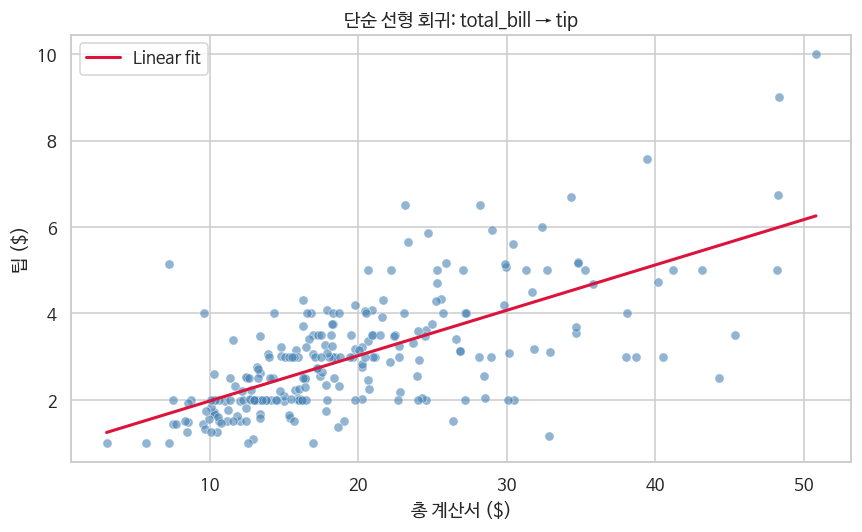

In [5]:
# 1. 도화지(Figure) 및 축(Axes) 설정
# 가로 8인치, 세로 5인치 크기의 그래프 창을 생성합니다.
fig, ax = plt.subplots(figsize=(8, 5))

# 2. 실제 데이터 분포 그리기 (산점도)
# total_bill(X축)과 tip(Y축)의 관계를 점으로 표현합니다.
# 데이터가 겹치는 부분을 확인하기 위해 투명도(alpha)를 0.6으로 설정하고, 색상은 steelblue를 사용합니다.
sns.scatterplot(data=df, x='total_bill', y='tip', alpha=0.6, ax=ax, color='steelblue')

# 3. 회귀 직선(Linear Fit Line) 생성을 위한 데이터 준비
# total_bill의 최솟값부터 최댓값까지 일정한 간격으로 100개의 데이터를 생성합니다.
# 모델 예측(.predict)에 입력값으로 사용할 수 있도록 2차원 배열(.reshape(-1, 1)) 형태로 변환합니다.
x_line = np.linspace(df['total_bill'].min(), df['total_bill'].max(), 100).reshape(-1, 1)

# 4. 회귀 직선 시각화 및 범례(Label) 지정
# 생성한 x_line 데이터에 대해 회귀 모델이 예측한 값을 선 그래프(plot)로 그립니다.
# 크림슨(crimson) 색상과 두께(linewidth) 2를 적용해 시각적 주목도를 높입니다.
ax.plot(x_line, lr.predict(x_line), color='crimson', linewidth=2, label='Linear fit')

# 5. 그래프 세부 정보(제목, 축 이름, 범례) 설정
ax.set_title('단순 선형 회귀: total_bill → tip') # 그래프의 제목 설정
ax.set_xlabel('총 계산서 ($)')                    # X축 레이블 설정
ax.set_ylabel('팁 ($)')                           # Y축 레이블 설정
ax.legend()                                       # 위에서 지정한 'Linear fit' 범례를 화면에 표시

# 6. 레이아웃 최적화 및 그래프 출력
# 그래프 구성 요소(제목, 축 레이블 등)가 잘리지 않도록 여백을 자동으로 조절합니다.
plt.tight_layout()
# 완성된 그래프를 화면에 노출합니다.
plt.show()

- 점들이 직선 주변에 모이면 **선형 가정**이 타당합니다.
- 곡선 패턴이 보이면 다항·비선형을 고려할 것.


---
## 2. 다항 회귀와 과적합


### 문제 6. 다항 회귀 — 차수(degree)별 곡선

**[개념 및 논문 리뷰]**
**다항 회귀**: $\hat{y} = w_0 + w_1 x + w_2 x^2 + \cdots + w_d x^d$

- degree ↑ → 표현력 ↑ → **train error ↓**
- degree 너무 ↑ → **과적합(overfitting)**: train은 완벽, **새 데이터**에서는 성능 급락

**Bias-Variance Trade-off**: 단순 모델(高 bias) vs 복잡 모델(高 variance).


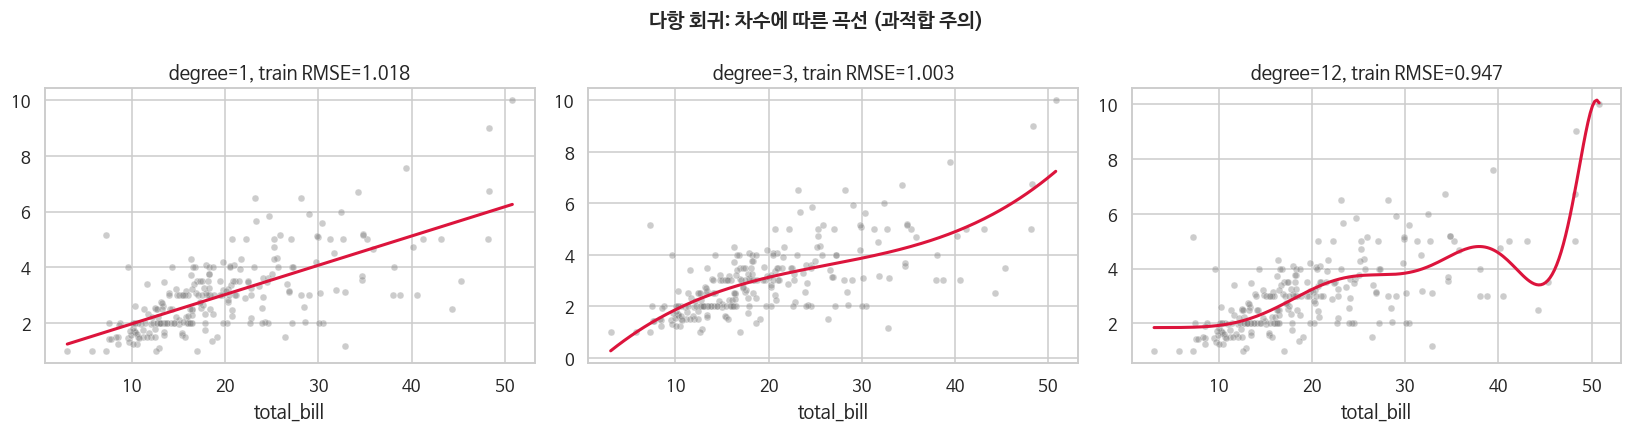

In [6]:
# 1. 시각화 및 모델 학습을 위한 데이터 준비
# 'total_bill'과 'tip' 데이터를 2차원/1차원 넘파이 배열로 추출합니다.
x_plot = df.loc[:, 'total_bill'].values.reshape(-1, 1)
y_plot = df.loc[:, 'tip'].values

# 모델이 예측한 다항 회귀 곡선을 매끄럽게 그리기 위해 최솟값부터 최댓값까지 200개의 조밀한 구간을 생성합니다.
x_grid = np.linspace(x_plot.min(), x_plot.max(), 200).reshape(-1, 1)

# 2. 비교할 다항식의 차수(Degree) 설정 및 서브플롯 정의
# 1차(선형), 3차(곡선), 12차(복잡한 고차원 선) 모델을 비교합니다.
degrees = [1, 3, 12]
fig, axes = plt.subplots(1, 3, figsize=(15, 4)) # 1행 3열 구조의 그래프 영역 생성
fig.suptitle('다항 회귀: 차수에 따른 곡선 (과적합 주의)', fontsize=13, fontweight='bold')

# 3. 차수별 모델 학습 및 시각화 반복문 수행
# zip을 활용해 3개의 축(ax)과 3개의 차수(deg)를 쌍으로 묶어 순회합니다.
for ax, deg in zip(axes, degrees):

    # [특성 공학] 지정된 차수만큼 독립변수를 고차항으로 변환할 객체 생성 (예: x -> x, x², x³...)
    poly = PolynomialFeatures(degree=deg, include_bias=False)
    X_poly = poly.fit_transform(x_plot)  # 원본 X 데이터를 고차원 다항식 특성으로 변환

    # 변환된 고차원 특성(X_poly)을 사용해 선형 회귀 모델 학습
    model = LinearRegression().fit(X_poly, y_plot)

    # 시각화용 x_grid 데이터도 모델의 입력 규격에 맞게 다항 특성으로 변환
    Xg = poly.transform(x_grid)

    # 실제 데이터 산점도 그리기 (배경 역할을 하도록 투명도 0.4와 회색 적용)
    sns.scatterplot(x=x_plot.ravel(), y=y_plot, alpha=0.4, ax=ax, color='gray', s=20)

    # 다항 회귀 모델이 예측한 값을 곡선 형태로 시각화
    ax.plot(x_grid, model.predict(Xg), color='crimson', linewidth=2)

    # 학습 데이터에 대한 RMSE(훈련 오차) 계산
    train_rmse = np.sqrt(mean_squared_error(y_plot, model.predict(X_poly)))

    # 서브플롯별 제목 및 X축 이름 설정 (차수가 올라갈수록 train RMSE는 줄어들지만 12차는 과적합이 발생함)
    ax.set_title(f'degree={deg}, train RMSE={train_rmse:.3f}')
    ax.set_xlabel('total_bill')

# 4. 레이아웃 최적화 및 그래프 출력
plt.tight_layout()
plt.show()

- degree=12면 train RMSE는 작아도 곡선이 **지그재그** 전형적인 과적합 발생


### 문제 7. Train vs Test RMSE — 과적합 수치로 확인
- 같은 데이터를 train/test로 나눠 degree별 **일반화 gap**을 봅니다.


In [9]:
from sklearn.model_selection import train_test_split

# 1. 독립변수(X)와 종속변수(y) 설정
X1 = df.loc[:, ['total_bill']].values
y1 = df.loc[:, 'tip'].values

# 2. 데이터를 훈련(Train)용과 검증(Test)용으로 분리
# 전체 데이터 중 70%는 모델 학습(X_tr, y_tr)에 사용하고, 나머지 30%는 모델 평가(X_te, y_te)에 사용합니다.
# random_state를 앞서 정의한 RANDOM_STATE(42)로 고정하여 실행 시마다 항상 동일하게 분리되도록 합니다.
X_tr, X_te, y_tr, y_te = train_test_split(X1, y1, test_size=0.3, random_state=RANDOM_STATE)

# 3. 차수별 모델 성능 기록을 위한 빈 리스트 생성
rows = []

# 4. 다양한 차수(1차부터 12차까지)에 대해 반복 수행하며 성능 평가
for deg in [1, 2, 3, 5, 8, 12]:
    # 다항 특성 변환 객체 생성
    poly = PolynomialFeatures(degree=deg, include_bias=False)

    # 훈련 데이터(Train)를 고차원 다항식 특성으로 변환 및 학습 기준 수립
    Xtr_p = poly.fit_transform(X_tr)
    # 테스트 데이터(Test)도 '훈련 데이터의 기준'에 맞춰 동일하게 다항 특성으로 변환
    Xte_p = poly.transform(X_te)

    # 변환된 훈련 데이터(Xtr_p)로 선형 회귀 모델 학습
    m = LinearRegression().fit(Xtr_p, y_tr)

    # 훈련 데이터와 테스트 데이터 각각의 예측 오차(RMSE) 계산 후 리스트에 추가
    # 차수가 너무 올라가면 train_rmse는 계속 떨어지지만, test_rmse는 급격히 치솟는 과적합 현상을 확인할 수 있습니다.
    rows.append({
        'degree': deg,
        'train_rmse': np.sqrt(mean_squared_error(y_tr, m.predict(Xtr_p))),
        'test_rmse': np.sqrt(mean_squared_error(y_te, m.predict(Xte_p))),
    })

# 5. 수집된 차수별 성능 결과를 보기 편하게 판다스 데이터프레임으로 변환 및 출력
pd.DataFrame(rows)

,degree,train_rmse,test_rmse
0,1,1.078303,0.867439
1,2,1.078261,0.867896
2,3,1.038653,0.954732
3,5,0.990360,0.917781
4,8,0.981269,0.926828
5,12,0.951007,0.976622


- test RMSE가 train보다 **훨씬 크고** degree↑와 함께 test만 악화되면 과적합
  + **`degree` (차수):** 독립변수 `total_bill`을 몇 차식까지 확장했는가입니다. 숫자가 커질수록 모델이 구불구불해지며 복잡해집니다.
  + **`train_rmse` (훈련 오차):** 모델이 학습할 때 사용한 데이터에 대한 평균 오차입니다.
  + **`test_rmse` (테스트 오차):** 모델이 한 번도 보지 못한 완전히 새로운 데이터에 대한 평균 오차입니다. 실제 모델의 예측 능력(일반화 성능)을 의미합니다.

- Train RMSE는 차수가 높아질수록 무조건 감소한다
  + **현상:** `degree=1`일 때 `1.078`이던 오차가 `degree=12`가 되면 `0.951`까지 **계속 줄어듭니다.**
  + **이유:** 모델이 복잡해질수록(차수가 커질수록) 학습 데이터의 세세한 굴곡과 노이즈까지 억지로 맞춰가며 훈련하기 때문입니다.

- Test RMSE는 특정 지점 이후 다시 증가한다 (과적합의 신호)
  + **현상:** `degree=1`에서 `degree=5`까지는 테스트 오차가 `0.867` $\rightarrow$ `0.917` 수준으로 어느 정도 유지되거나 적정선을 찾다가, 최고 차수인 `degree=12`가 되면 `0.976`으로 **다시 껑충 뛰어오릅니다.**
  + **이유:** 12차 모델은 훈련 데이터에 너무 과하게 끼워 맞춰진 나머지(Overfitting), 새로운 데이터가 들어왔을 때는 오히려 엉뚱한 예측을 하여 오차가 커진 것입니다.

- 결론: 최적의 모델(의사결정)은 머신러닝에서는 **`train_rmse`가 낮으면서 동시에 `test_rmse`도 가장 안정적으로 낮은 지점**을 찾아야 합니다.
  + **degree = 1 또는 2:**
    - `train_rmse`와 `test_rmse`가 안정적입니다. 특히 이 데이터셋에서는 단순 선형 회귀(`degree=1`) 스타일이 테스트 오차(`0.867`) 기준 가장 성능이 좋습니다. 데이터가 단순한 선형적 관계에 가깝기 때문입니다.
  + **degree = 12 (과적합, Overfitting):**
    - 훈련 오차는 가장 낮지만 테스트 오차가 커지므로 실제 서비스나 예측에는 사용할 수 없는 쓰레기 모델입니다.



- ** 한 줄 요약**
  + "식당 팁 데이터는 굳이 곡선(고차식)으로 복잡하게 풀 필요 없이, **1차 선형 모델(혹은 2차)을 쓰는 것이 새로운 손님의 팁을 예측할 때 가장 정확하고 안전하다**"는 것을 증명하는 결과 표.


---
## 3. 회귀 평가 지표 — 올바른 선택 가이드


### 문제 8. RMSE · MSE · MAE — 논문 기반 비교

- **Chai & Draxler (2014)** — *Root mean square error (RMSE) or mean absolute error (MAE)?*
Geoscientific Model Development, 7, 1247–1250.
- **MSE/RMSE**: 오차 **제곱** → **이상치(outlier)** 에 **민감** (큰 오차가 지표를 크게 끌어올림)
- RMSE = √MSE → 원본 $y$와 **같은 단위** ($)

**Willmott & Matsuura (2005)** — MAE 관련 문헌
- **MAE**: $|y - \hat{y}|$ 평균 → **이상치에 robust**
- **실무**: 이상치가 많거나 "큰 실수 몇 번"보다 "평균적으로 얼마나 틀리나"가 중요할 때 MAE 선호

| 지표 | 이상치 | 단위 | 해석 |
|------|--------|------|------|
| MSE | 민감 | y² | 페널티 큼 |
| RMSE | 민감 | y | MSE와 동일 민감도, 해석 용이 |
| MAE | robust | y | 중앙적 오차 크기 |


In [13]:
import numpy as np
from sklearn.metrics import mean_squared_error, mean_absolute_error

y_ex = np.array([2.0, 2.5, 3.0, 2.8, 3.2])
yhat_ex = np.array([2.1, 2.4, 3.1, 2.7, 3.0])

rmse = np.sqrt(mean_squared_error(y_ex, yhat_ex))
mae = mean_absolute_error(y_ex, yhat_ex)

# f-string 변수명 뒤에 :.4f를 붙여 소수점 4자리까지 출력 통제
print(f'정상 5점 — RMSE: {rmse:.4f} MAE: {mae:.4f}')

정상 5점 — RMSE: 0.1265 MAE: 0.1200


### 문제 9. 이상치 주입 실험 — RMSE vs MAE 반응

- 한 점에 **큰 오차**를 넣어 지표 변화를 비교합니다.


In [14]:
# 1. 원본 데이터 및 예측값 복사
y_clean = y_hat.copy()      # 앞서 선형 회귀 모델이 예측한 값(ŷ) 복사
y_true_full = y.copy()      # 실제 팁 정답값(y) 복사

# 2. 인위적인 대형 이상치(Outlier) 데이터 생성
# 원본 정답을 복사한 뒤, 상위 5개 샘플의 실제 팁 금액을 원래보다 10달러 더 많이 준 것으로 조작합니다.
y_bad = y_true_full.copy()
y_bad[:5] = y_bad[:5] + 10.0

# 상위 5개 샘플에 대한 모델의 예측값은 오히려 원래보다 10달러 낮게 조작합니다.
# 결과적으로 상위 5개 샘플은 실제값과 예측값의 차이(오차)가 무려 '20달러'에 달하는 극단적인 이상치가 됩니다.
y_pred_bad = y_hat.copy()
y_pred_bad[:5] = y_pred_bad[:5] - 10.0

# 3. 이상치가 없을 때 vs 있을 때의 평가지표 계산
# [Clean] 이상치가 없는 정상 데이터셋의 RMSE, MAE 계산
rmse_clean = np.sqrt(mean_squared_error(y_true_full, y_hat))
mae_clean = mean_absolute_error(y_true_full, y_hat)

# [Bad] 극단적인 이상치 5건이 포함된 데이터셋의 RMSE, MAE 계산
rmse_bad = np.sqrt(mean_squared_error(y_bad, y_pred_bad))
mae_bad = mean_absolute_error(y_bad, y_pred_bad)

# 4. 결과 및 지표별 증가율(민감도) 출력
print(f'이상치 없음 — RMSE: {rmse_clean:.3f}, MAE: {mae_clean:.3f}')
print(f'이상치 5건 — RMSE: {rmse_bad:.3f}, MAE: {mae_bad:.3f}')

# 이상치 추가 후 각 지표가 몇 %나 증가(악화)했는지 계산하여 비교합니다.
# RMSE는 오차를 '제곱'한 뒤 평균을 내기 때문에, 큰 오차(이상치)에 극도로 민감하여 MAE보다 훨씬 높은 증가율을 보입니다.
print(f'RMSE 증가율: {(rmse_bad/rmse_clean-1)*100:.1f}%')
print(f'MAE   증가율: {(mae_bad/mae_clean-1)*100:.1f}%')

이상치 없음 — RMSE: 1.018, MAE: 0.746
이상치 5건 — RMSE: 2.993, MAE: 1.138
RMSE 증가율: 194.1%
MAE   증가율: 52.6%


- **RMSE는 이상치에 극도로 민감합니다 (194.1% 폭등):** 큰 오차를 제곱하여 반영하는 특성 때문에, 단 5건의 이상치만으로도 오차가 정상 수준의 약 3배 가까이 기하급수적으로 폭증했습니다.
- **MAE는 이상치에 상대적으로 강건합니다 (52.6% 증가):** 오차의 절대값 크기만 선형적으로 더해 평균을 내기 때문에, 대형 이상치가 포함되더라도 RMSE에 비해 충격을 훨씬 덜 받습니다.

- **결론:** 데이터셋에 유독 큰 이상치가 많을 때 모델의 패널티를 강하게 주고 싶다면 **RMSE**를, 이상치에 흔들리지 않는 평균적인 예측 성능을 측정하고 싶다면 **MAE**가 적합합니다.


### 문제 10. 지표 비교 Bar Chart + Part 1 마무리
- 이상치 전·후 RMSE/MAE를 **막대그래프**로 비교합니다.


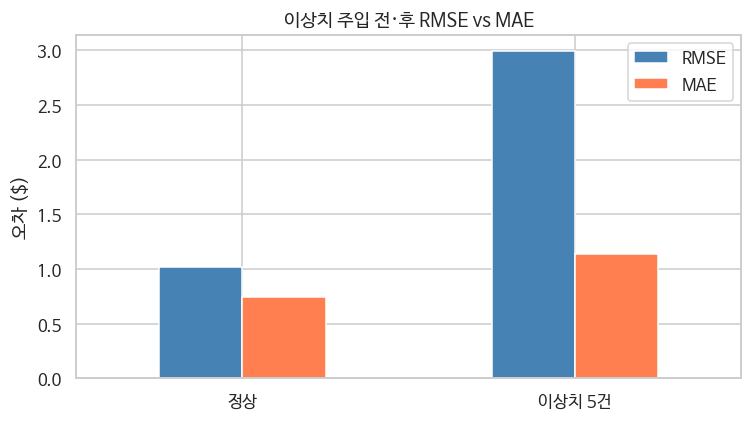


=== Part 1 체크리스트 ===
[✓] MSE / Gradient Descent 개념
[✓] 다항 회귀 과적합 시각화
[✓] RMSE vs MAE (Chai & Draxler, Willmott & Matsuura)
→ Part 2: Pipeline · Data Leakage · CV 분할


In [15]:
# 1. 시각화를 위한 평가지표 데이터프레임 생성
# 정상 상태와 이상치 5건이 주입된 상태의 RMSE, MAE 값을 매핑하여 테이블 구조를 만듭니다.
metrics_df = pd.DataFrame({
    'RMSE': [rmse_clean, rmse_bad],
    'MAE': [mae_clean, mae_bad],
}, index=['정상', '이상치 5건'])

# 2. 막대그래프(Bar Chart) 시각화 설정
fig, ax = plt.subplots(figsize=(7, 4)) # 가로 7, 세로 4인치의 도화지 생성

# 판다스의 내장 plot 기능을 활용해 막대그래프를 그립니다. (RMSE와 MAE 색상 구분)
metrics_df.plot(kind='bar', ax=ax, color=['steelblue', 'coral'])

# 3. 그래프 스타일 및 텍스트 레이블 추가
ax.set_title('이상치 주입 전·후 RMSE vs MAE')  # 그래프 제목 설정
ax.set_ylabel('오차 ($)')                       # Y축 단위 레이블 설정
ax.tick_params(axis='x', rotation=0)          # X축 인덱스 라벨('정상', '이상치 5건')이 회전하지 않고 똑바로 서도록 설정

# 4. 레이아웃 최적화 및 화면 출력
plt.tight_layout()
plt.show()

# 5. 지금까지 학습한 데이터 분석/모델 평가 핵심 개념 체크리스트 출력
print('\n=== Part 1 체크리스트 ===')
print('[✓] MSE / Gradient Descent 개념')                       # 비용 함수와 최적화의 기본 원리
print('[✓] 다항 회귀 과적합 시각화')                             # 차수(Degree) 증가에 따른 변동성 확인 완료
print('[✓] RMSE vs MAE (Chai & Draxler, Willmott & Matsuura)')  # 학술적으로도 유명한 두 지표의 오차 민감도 비교 완료